# Detector de Fraudes com Redes Neurais
`
Dessa vez, será utilizado uma MLP para obter melhores resultados
`

In [1]:
from google.colab import drive
# Montando o drive onde se encontra o data set;
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Observação:**
`
A base de dados usada pode ser encontrada em: 
""
`

In [2]:
!mkdir dataset
!cp drive/MyDrive/creditcard.csv dataset 

mkdir: cannot create directory ‘dataset’: File exists


In [3]:
import pandas as pd
df = pd.read_csv("dataset/creditcard.csv")

In [4]:
# Verificando os atributos do dataset
print(len(df.columns))
print("Quantidade de dados:",len(df))


31
Quantidade de dados: 284807


In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(df.select_dtypes(include=object))

# Não existem dados categóricos

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[284807 rows x 0 columns]


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


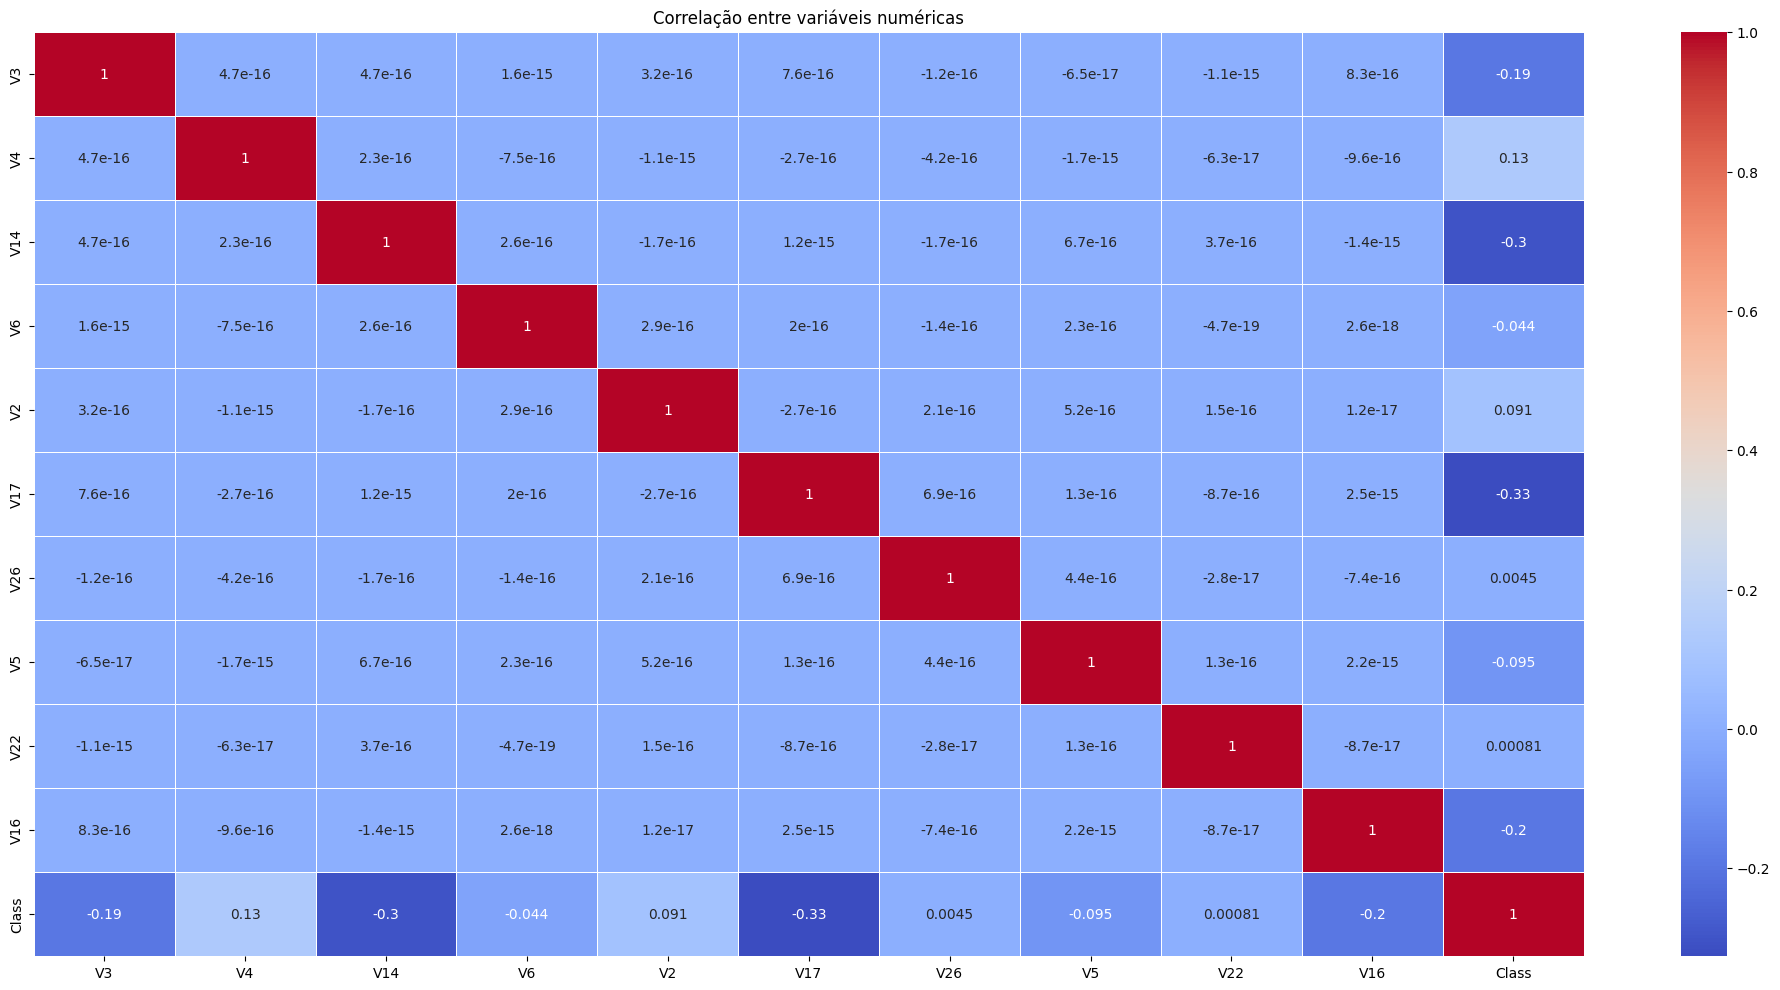

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

conjunto_cols = df.columns.to_series().sample(10).tolist()
conjunto_cols.append("Class")

# Correlações entre as variáveis numéricas
plt.figure(figsize=(25, 12))
sns.heatmap(df[conjunto_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlação entre variáveis numéricas")
plt.show()

In [8]:
new_df = df.copy()
new_df.isna().sum() >=1 

,0
Time,False
V1,False
V2,False
V3,False
V4,False
V5,False
V6,False
V7,False
V8,False
V9,False


In [9]:
# Priorizar os casos em que a variável "Fraud_Label" é igual a 1 (fraude)
fraud_cases = new_df[new_df["Class"] == 1]
not_fraud_cases = len(new_df[new_df["Class"] == 0])

print(f"Total de casos de fraude: {len(fraud_cases)}")
print(f"Total de casos não fraude: {not_fraud_cases}")

Total de casos de fraude: 492
Total de casos não fraude: 284315


In [10]:
# Criando meu próprio split de treino e teste, priorizando os casos de fraude
def split_data(df, target, random_state=42):
    # Separando as features e o target
    X = df.drop(columns=[target])
    y = df[target]
    
    # calculando o número de amostras para treino e teste, priorizando os casos de fraude para o treino 
    n_global = len(df)
    n_train = int(0.6 * n_global)

    # positivos
    pos_idx = y[y==1].index
    neg_idx = y[y==0].index
    
    n_pos_train = int(0.8 * len(pos_idx))
    n_neg_train = n_train - n_pos_train

    # Amostragem dos índices para treino e teste
    pos_train_idx = pos_idx.to_series().sample(
        n=n_pos_train, random_state=random_state
    ).index

    neg_train_idx = neg_idx.to_series().sample(
        n=n_neg_train, random_state=random_state
    ).index

    train_idx = pos_train_idx.union(neg_train_idx)
    test_idx = df.index.difference(train_idx)

    # Separação dos dados de treino e teste
    X_train = X.loc[train_idx]
    y_train = y.loc[train_idx]
    X_test = X.loc[test_idx]
    y_test = y.loc[test_idx]

    return X_train, y_train, X_test, y_test


In [11]:
x_train, y_train, x_test, y_test = split_data(new_df, target="Class")

In [12]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, regularizers

def create_model(dropout_rate=0.5, l2_reg=1e-4):

    model = keras.Sequential([
        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate * 0.9),
        
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate * 0.8),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate * 0.6),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate * 0.4),

        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.Dense(
            16,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.Dense(1, activation="sigmoid")
    ])

    return model


In [13]:
from keras.metrics import Precision, Recall, AUC
from keras.optimizers import Adam

model = create_model()

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy", Precision(), Recall(), AUC()]
)

In [14]:
normalize_cols = x_train.columns.to_list()
normalize_cols

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_norm", num_pipeline, normalize_cols)
    ],
    remainder="passthrough"
)


In [16]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])


In [17]:
# Treinando o modelo
pipeline.fit(x_train, y_train, model__epochs=200, model__validation_split=0.2, model__callbacks=[EarlyStopping(patience=7)])

Epoch 1/200
4273/4273 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9806 - auc: 0.6763 - loss: 0.1868 - precision: 0.0047 - recall: 0.0352 - val_accuracy: 0.9994 - val_auc: 0.9049 - val_loss: 0.0708 - val_precision: 1.0000 - val_recall: 0.6724
Epoch 2/200
2771/4273 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9982 - auc: 0.9139 - loss: 0.0734 - precision: 0.8365 - recall: 0.3109

KeyboardInterrupt: 

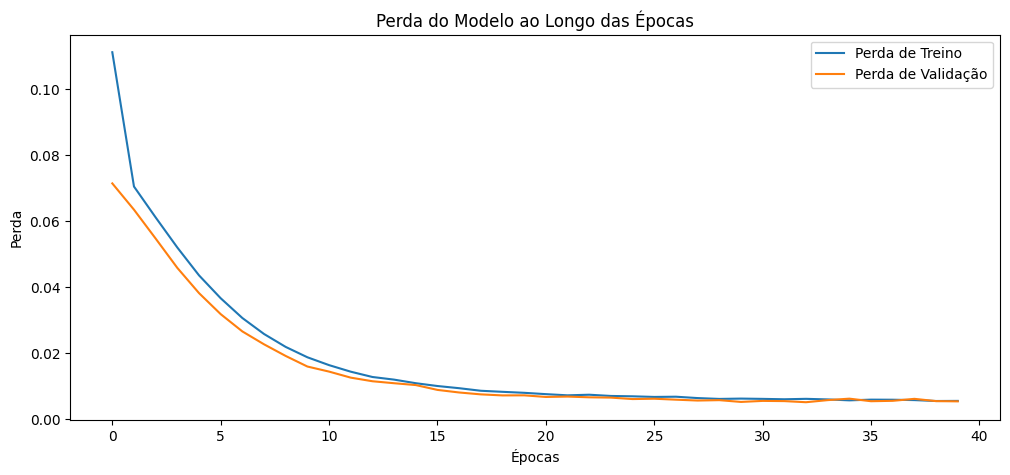

In [ ]:
model = pipeline.named_steps["model"]
history = model.history.history

# Vizualização da perda do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history["loss"], label="Perda de Treino")
plt.plot(history["val_loss"], label="Perda de Validação")
plt.title("Perda do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()
plt.show()

In [ ]:
hist = list(history.keys())
hist

['accuracy',
 'auc_2',
 'loss',
 'precision_2',
 'recall_2',
 'val_accuracy',
 'val_auc_2',
 'val_loss',
 'val_precision_2',
 'val_recall_2']

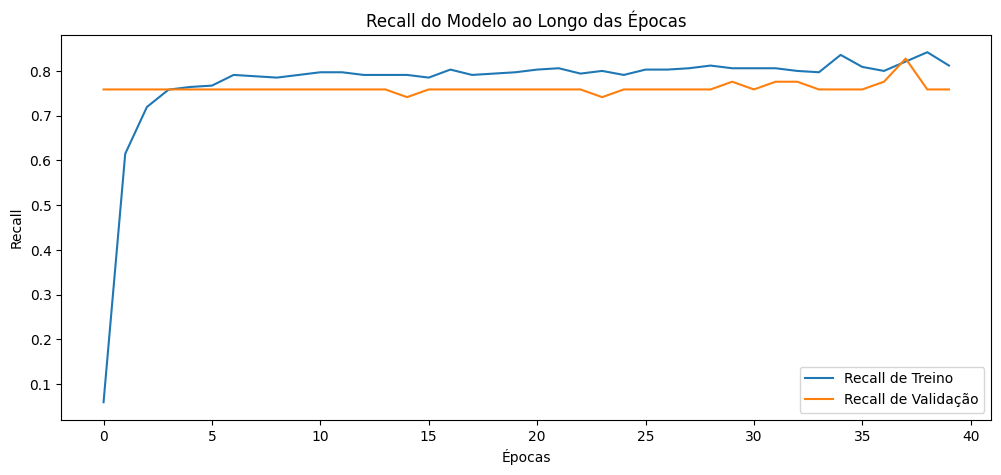

In [ ]:
# Visualização do recall do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history[hist[4]], label="Recall de Treino")
plt.plot(history[hist[9]], label="Recall de Validação")
plt.title("Recall do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = pipeline.predict(x_test)
y_pred_classes = (y_pred >= 0.1).astype(int)


3561/3561 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


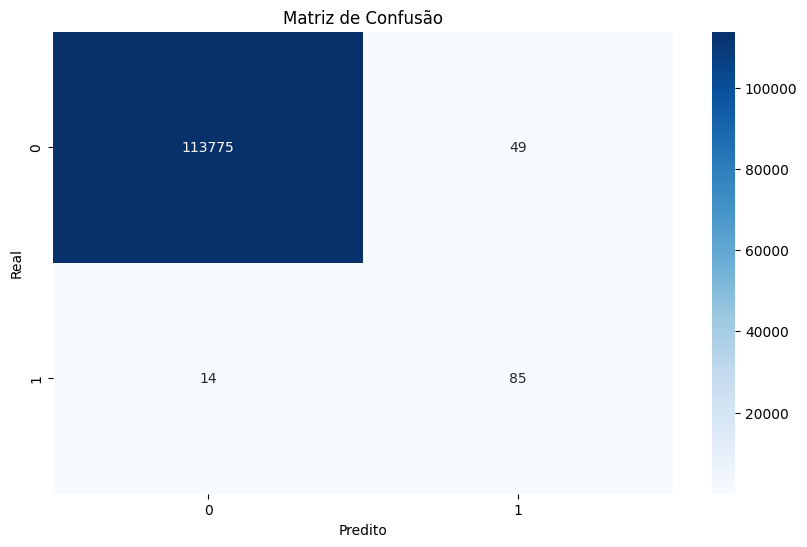

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [ ]:
precision = Precision()
recall = Recall()
auc = AUC()

In [ ]:
precision.update_state(y_test, y_pred_classes)
recall.update_state(y_test, y_pred_classes)
auc.update_state(y_test, y_pred_classes)

print(f"Precision: {precision.result().numpy():.4f}")
print(f"Recall: {recall.result().numpy():.4f}")
print(f"AUC: {auc.result().numpy():.4f}")

Precision: 0.6343
Recall: 0.8586
AUC: 0.9291


# 2° Modelo;
**Testando uma abordagem com menos dados**

In [ ]:
# Reduzindo o df em 50%
porcent_frauds = len(new_df[new_df["Class"] == 1]) / len(new_df)
print(f"Porcentagem de fraudes no df: {porcent_frauds * 100:.2f}%")
print(f"50% do Total: {int(len(new_df) / 2)}")

# Casos de fraudes
fraud = new_df[new_df["Class"] == 1]
fraud_new = pd.DataFrame(fraud).sample(int(len(fraud) * 0.5), random_state=42)

Porcentagem de fraudes no df: 0.17%
50% do Total: 142403


In [ ]:
# Casos de não fraudes
not_fraud = new_df[new_df["Class"] == 0]
not_fraud_new = pd.DataFrame(not_fraud).sample(int(len(not_fraud) * 0.5), random_state=42)

In [ ]:
# Concatenando ambos dataframes
new_data_frame = pd.concat([fraud_new, not_fraud_new], axis=0)

new_data_frame = new_data_frame.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
"Total dos dados: " + str(len(new_data_frame))

'Total dos dados: 142403'

In [ ]:
x_train2, y_train2, x_test2, y_test2 = split_data(new_data_frame, target="Class")

In [ ]:
pipeline2 = pipeline

pipeline2.fit(x_train2, y_train2, model__epochs=200, model__validation_split=0.2, model__callbacks=[EarlyStopping(patience=7)])

Epoch 1/200
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9993 - auc_2: 0.9743 - loss: 0.0051 - precision_2: 0.8668 - recall_2: 0.8141 - val_accuracy: 0.9991 - val_auc_2: 0.9201 - val_loss: 0.0085 - val_precision_2: 0.8919 - val_recall_2: 0.7500
Epoch 2/200
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9996 - auc_2: 0.9558 - loss: 0.0043 - precision_2: 0.8966 - recall_2: 0.8778 - val_accuracy: 0.9992 - val_auc_2: 0.9088 - val_loss: 0.0075 - val_precision_2: 0.9189 - val_recall_2: 0.7727
Epoch 3/200
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9993 - auc_2: 0.9515 - loss: 0.0050 - precision_2: 0.8114 - recall_2: 0.8568 - val_accuracy: 0.9991 - val_auc_2: 0.9199 - val_loss: 0.0085 - val_precision_2: 0.8919 - val_recall_2: 0.7500
Epoch 4/200
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9995 - auc_2: 0.9739 - loss: 0.0044 - precision_2: 0.8851 - recall_2: 0.8933 - val_accuracy: 0.9991 - val_auc_2: 0.8974 - val_loss: 0.0089 - val_precisi

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_norm',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model', <Sequential name=sequential_2, built=True>)])

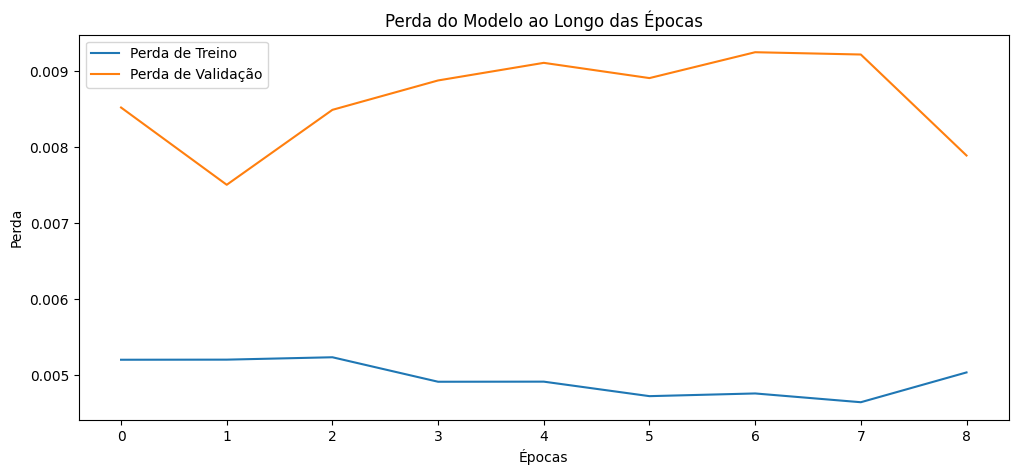

In [ ]:
model2 = pipeline2.named_steps["model"]
history2 = model2.history.history
hist2 = list(history2)

# Vizualização da perda do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history2["loss"], label="Perda de Treino")
plt.plot(history2["val_loss"], label="Perda de Validação")
plt.title("Perda do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()
plt.show()

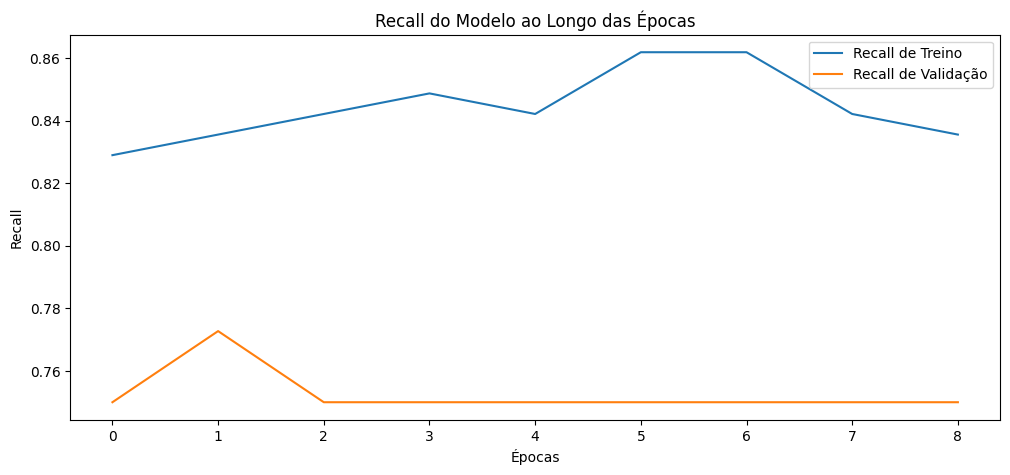

In [ ]:
# Visualização do recall do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history2[hist[4]], label="Recall de Treino")
plt.plot(history2[hist[9]], label="Recall de Validação")
plt.title("Recall do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [ ]:
y_pred2 = pipeline2.predict(x_test2)
y_pred2_classes = (y_pred2 >= 0.1).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


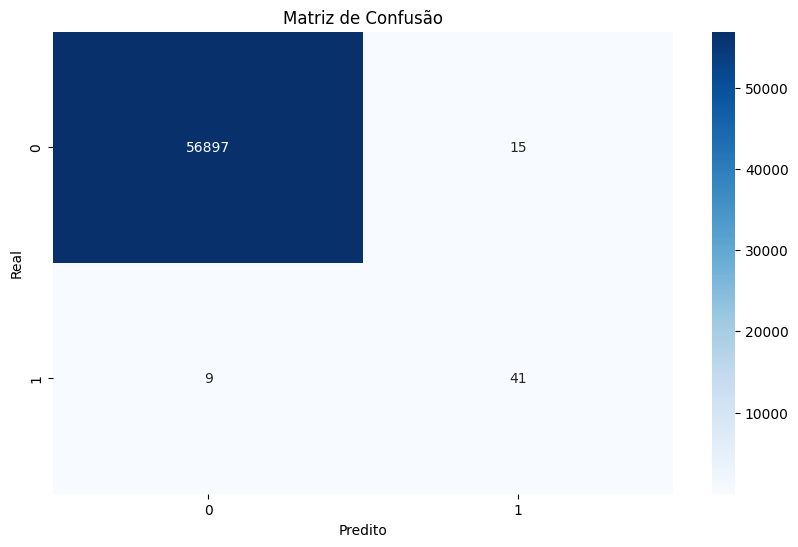

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test2, y_pred2_classes), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [ ]:
precision.update_state(y_test2, y_pred2_classes)
recall.update_state(y_test2, y_pred2_classes)
auc.update_state(y_test2, y_pred2_classes)

print(f"Precision: {precision.result().numpy():.4f}")
print(f"Recall: {recall.result().numpy():.4f}")
print(f"AUC: {auc.result().numpy():.4f}")

Precision: 0.6632
Recall: 0.8456
AUC: 0.9226


# 3° Teste 
**Diminuindo os dados para 25% do total**

In [ ]:
# Reduzindo o df em 25%
porcent_frauds2 = len(new_data_frame[new_data_frame["Class"] == 1]) / len(new_data_frame)
print(f"Porcentagem de fraudes no df: {porcent_frauds2 * 100:.2f}%")
print(f"25% do Total: {int(len(new_data_frame) / 2)}")

# Casos de fraudes
fraud2 = new_data_frame[new_data_frame["Class"] == 1]
fraud_new2 = pd.DataFrame(fraud2).sample(int(len(fraud2) * 0.5), random_state=42)

Porcentagem de fraudes no df: 0.17%
25% do Total: 71201


In [ ]:
# Casos de não fraudes
not_fraud2 = new_data_frame[new_data_frame["Class"] == 0]
not_fraud_new2 = pd.DataFrame(not_fraud2).sample(int(len(not_fraud2) * 0.5), random_state=42)

In [ ]:
# Concatenando ambos dataframes
new_data_frame2 = pd.concat([fraud_new2, not_fraud_new2], axis=0)
new_data_frame2 = new_data_frame2.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
"Total dos dados: " + str(len(new_data_frame2))

'Total dos dados: 71201'

In [ ]:
x_train3, y_train3, x_test3, y_test3 = split_data(new_data_frame2, target="Class")

In [ ]:
pipeline3 = pipeline

pipeline3.fit(x_train3, y_train3, model__epochs=200, model__validation_split=0.2, model__callbacks=[EarlyStopping(patience=7)])

Epoch 1/200
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9993 - auc_2: 0.9472 - loss: 0.0064 - precision_2: 0.9040 - recall_2: 0.8390 - val_accuracy: 0.9994 - val_auc_2: 0.9999 - val_loss: 0.0050 - val_precision_2: 0.7895 - val_recall_2: 0.9375
Epoch 2/200
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9992 - auc_2: 0.9651 - loss: 0.0057 - precision_2: 0.8470 - recall_2: 0.7903 - val_accuracy: 0.9994 - val_auc_2: 0.9686 - val_loss: 0.0049 - val_precision_2: 0.7895 - val_recall_2: 0.9375
Epoch 3/200
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9993 - auc_2: 0.9735 - loss: 0.0044 - precision_2: 0.8184 - recall_2: 0.8300 - val_accuracy: 0.9994 - val_auc_2: 0.9687 - val_loss: 0.0051 - val_precision_2: 0.7895 - val_recall_2: 0.9375
Epoch 4/200
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9991 - auc_2: 0.9639 - loss: 0.0050 - precision_2: 0.7990 - recall_2: 0.8237 - val_accuracy: 0.9995 - val_auc_2: 0.9998 - val_loss: 0.0040 - val_precision

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_norm',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model', <Sequential name=sequential_2, built=True>)])

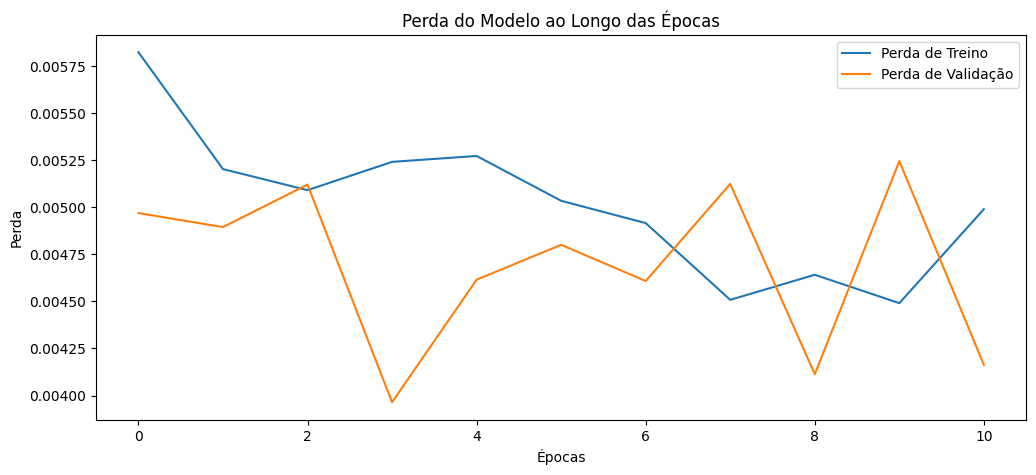

In [ ]:
model3 = pipeline3.named_steps["model"]
history3 = model3.history.history
hist3 = list(history3)

# Vizualização da perda do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history3["loss"], label="Perda de Treino")
plt.plot(history3["val_loss"], label="Perda de Validação")
plt.title("Perda do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()
plt.show()

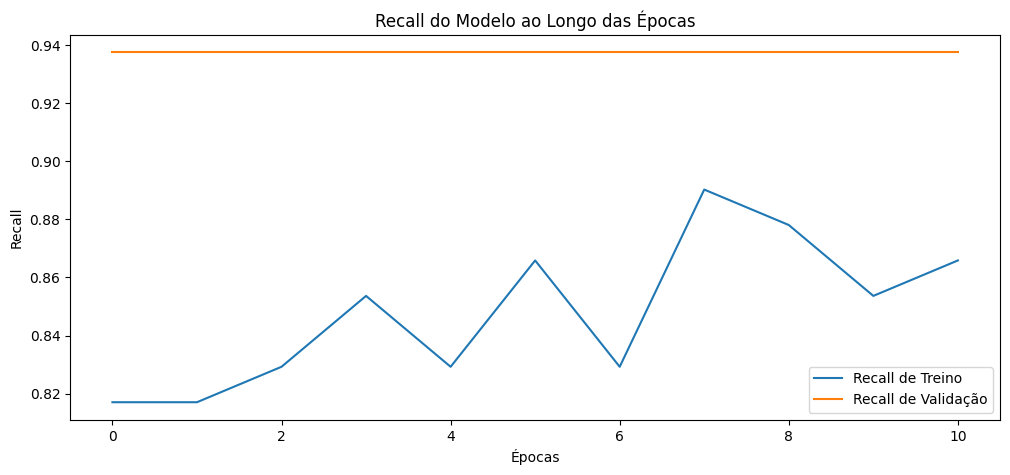

In [ ]:
# Visualização do recall do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history3[hist3[4]], label="Recall de Treino")
plt.plot(history3[hist3[9]], label="Recall de Validação")
plt.title("Recall do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [ ]:
y_pred3 = pipeline3.predict(x_test3)
y_pred3_classes = (y_pred3 >= 0.1).astype(int)

891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


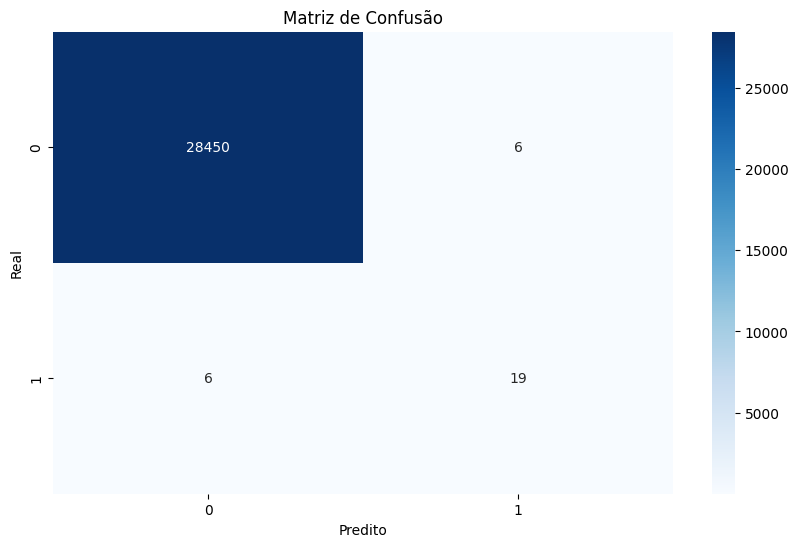

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test3, y_pred3_classes), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [ ]:
precision.update_state(y_test3, y_pred3_classes)
recall.update_state(y_test3, y_pred3_classes)
auc.update_state(y_test3, y_pred3_classes)

print(f"Precision: {precision.result().numpy():.4f}")
print(f"Recall: {recall.result().numpy():.4f}")
print(f"AUC: {auc.result().numpy():.4f}")

Precision: 0.6744
Recall: 0.8333
AUC: 0.9165


# Avaliando métricas

In [ ]:
from keras.metrics import F1Score

f1_modelo1 = F1Score()